**PROJECT 1 - STUDENT MARKS PREDICTION**

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
df=pd.read_csv('ultimate_student_productivity_dataset_5000.csv')

In [44]:
df

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,Good,8,38.11,39.53,59.23,27.81
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,20,Other,Undergraduate,3.93,1.42,0.54,2.58,2.62,9.30,...,113,496,0,0,Good,9,35.55,33.24,48.83,22.51
4996,4997,24,Male,High School,4.00,0.00,3.00,4.45,2.47,6.42,...,146,411,0,1,Poor,5,16.87,59.07,23.32,2.00
4997,4998,22,Male,Undergraduate,5.63,2.52,2.89,3.58,1.07,6.65,...,123,306,0,1,Good,7,23.85,47.72,41.09,27.89
4998,4999,17,Male,Undergraduate,3.58,2.83,1.53,5.88,1.28,7.36,...,54,304,1,1,Good,4,13.04,58.90,12.62,3.63


In [45]:
df.isnull().sum()

student_id              0
age                     0
gender                  0
academic_level          0
study_hours             0
self_study_hours        0
online_classes_hours    0
social_media_hours      0
gaming_hours            0
sleep_hours             0
screen_time_hours       0
exercise_minutes        0
caffeine_intake_mg      0
part_time_job           0
upcoming_deadline       0
internet_quality        0
mental_health_score     0
focus_index             0
burnout_level           0
productivity_score      0
exam_score              0
dtype: int64

In [46]:
df=df.drop(['student_id','age','gender','exercise_minutes','caffeine_intake_mg','part_time_job','internet_quality','upcoming_deadline','focus_index','burnout_level'],axis=1)

In [47]:
df

,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,mental_health_score,productivity_score,exam_score
0,High School,7.64,1.56,2.20,3.05,2.19,6.52,6.47,10,73.65,50.16
1,High School,2.21,2.22,2.10,1.65,2.55,5.97,6.05,3,13.70,1.00
2,High School,3.45,0.00,0.29,1.34,2.08,8.39,7.62,8,45.15,18.30
3,High School,5.75,2.08,3.01,2.27,2.20,6.31,11.67,3,20.92,9.37
4,High School,6.83,1.72,3.33,2.65,0.70,8.01,10.02,8,59.23,27.81
...,...,...,...,...,...,...,...,...,...,...,...
4995,Undergraduate,3.93,1.42,0.54,2.58,2.62,9.30,6.38,9,48.83,22.51
4996,High School,4.00,0.00,3.00,4.45,2.47,6.42,7.32,5,23.32,2.00
4997,Undergraduate,5.63,2.52,2.89,3.58,1.07,6.65,9.51,7,41.09,27.89
4998,Undergraduate,3.58,2.83,1.53,5.88,1.28,7.36,8.31,4,12.62,3.63


In [48]:
df['academic_level'].value_counts()

academic_level
Postgraduate     1687
High School      1672
Undergraduate    1641
Name: count, dtype: int64

In [49]:
df['academic_level']=df['academic_level'].map({'Postgraduate':2,'Undergraduate':1,'High School':0})

In [50]:
df

,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,mental_health_score,productivity_score,exam_score
0,0,7.64,1.56,2.20,3.05,2.19,6.52,6.47,10,73.65,50.16
1,0,2.21,2.22,2.10,1.65,2.55,5.97,6.05,3,13.70,1.00
2,0,3.45,0.00,0.29,1.34,2.08,8.39,7.62,8,45.15,18.30
3,0,5.75,2.08,3.01,2.27,2.20,6.31,11.67,3,20.92,9.37
4,0,6.83,1.72,3.33,2.65,0.70,8.01,10.02,8,59.23,27.81
...,...,...,...,...,...,...,...,...,...,...,...
4995,1,3.93,1.42,0.54,2.58,2.62,9.30,6.38,9,48.83,22.51
4996,0,4.00,0.00,3.00,4.45,2.47,6.42,7.32,5,23.32,2.00
4997,1,5.63,2.52,2.89,3.58,1.07,6.65,9.51,7,41.09,27.89
4998,1,3.58,2.83,1.53,5.88,1.28,7.36,8.31,4,12.62,3.63


In [51]:
df

,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,mental_health_score,productivity_score,exam_score
0,0,7.64,1.56,2.20,3.05,2.19,6.52,6.47,10,73.65,50.16
1,0,2.21,2.22,2.10,1.65,2.55,5.97,6.05,3,13.70,1.00
2,0,3.45,0.00,0.29,1.34,2.08,8.39,7.62,8,45.15,18.30
3,0,5.75,2.08,3.01,2.27,2.20,6.31,11.67,3,20.92,9.37
4,0,6.83,1.72,3.33,2.65,0.70,8.01,10.02,8,59.23,27.81
...,...,...,...,...,...,...,...,...,...,...,...
4995,1,3.93,1.42,0.54,2.58,2.62,9.30,6.38,9,48.83,22.51
4996,0,4.00,0.00,3.00,4.45,2.47,6.42,7.32,5,23.32,2.00
4997,1,5.63,2.52,2.89,3.58,1.07,6.65,9.51,7,41.09,27.89
4998,1,3.58,2.83,1.53,5.88,1.28,7.36,8.31,4,12.62,3.63


In [52]:
df.corr()

,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,mental_health_score,productivity_score,exam_score
academic_level,1.000000,-0.005352,-0.006271,-0.011407,-0.012771,0.002351,-0.028082,-0.030137,0.007943,-0.000377,-0.005366
study_hours,-0.005352,1.000000,-0.003942,0.011238,-0.000296,0.017475,-0.027995,-0.022899,-0.013122,0.637981,0.513434
self_study_hours,-0.006271,-0.003942,1.000000,-0.010100,-0.015582,0.000569,-0.007138,-0.016264,0.011482,0.057781,0.083602
online_classes_hours,-0.011407,0.011238,-0.010100,1.000000,-0.011796,-0.006788,-0.013043,-0.022199,-0.006295,0.003215,0.004975
social_media_hours,-0.012771,-0.000296,-0.015582,-0.011796,1.000000,0.010251,0.003535,-0.016412,-0.008081,-0.070052,-0.106116
gaming_hours,0.002351,0.017475,0.000569,-0.006788,0.010251,1.000000,-0.022217,-0.005403,-0.008616,-0.029411,-0.054506
sleep_hours,-0.028082,-0.027995,-0.007138,-0.013043,0.003535,-0.022217,1.000000,-0.009720,0.002122,0.149666,0.234710
screen_time_hours,-0.030137,-0.022899,-0.016264,-0.022199,-0.016412,-0.005403,-0.009720,1.000000,0.015780,-0.089953,-0.131940
mental_health_score,0.007943,-0.013122,0.011482,-0.006295,-0.008081,-0.008616,0.002122,0.015780,1.000000,0.630605,0.546547
productivity_score,-0.000377,0.637981,0.057781,0.003215,-0.070052,-0.029411,0.149666,-0.089953,0.630605,1.000000,0.886401


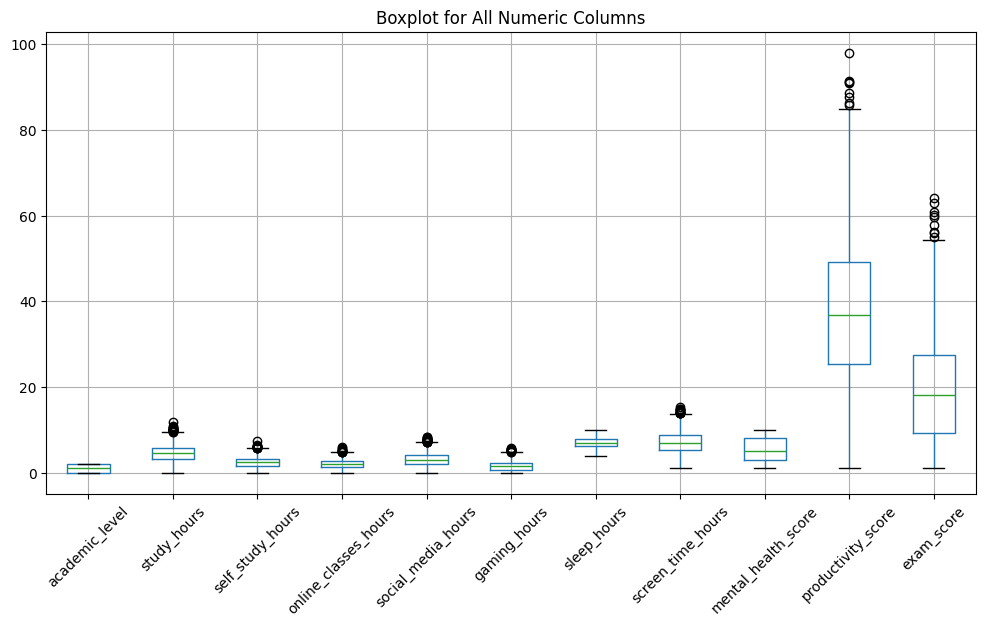

In [53]:

numeric_df = df.select_dtypes(include='number')
numeric_df.boxplot(figsize=(12,6))
plt.xticks(rotation=45)
plt.title("Boxplot for All Numeric Columns")
plt.show()

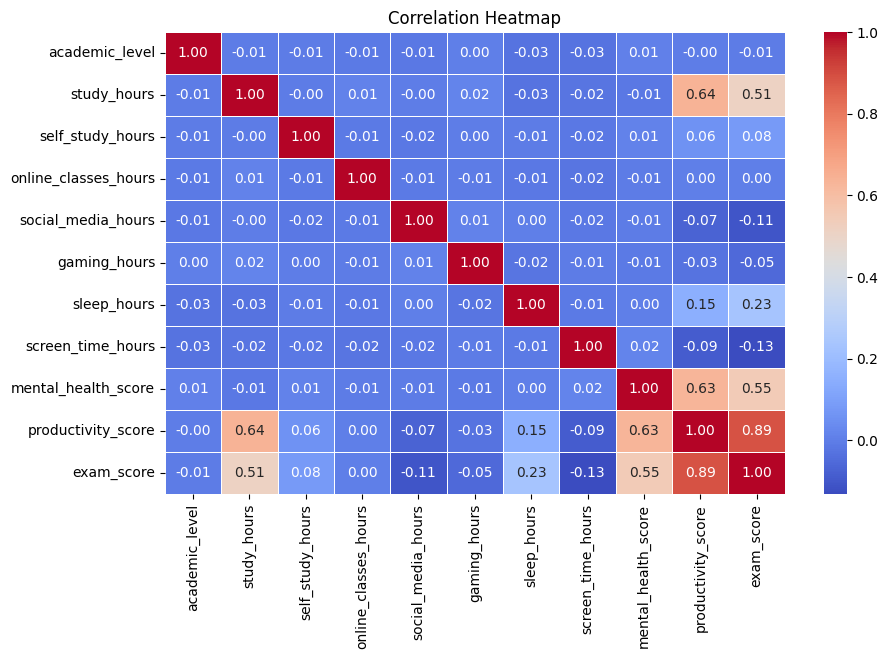

In [54]:
corr_matrix = numeric_df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, 
            annot=True,        # show values
            cmap='coolwarm',   # color theme
            fmt=".2f",         # 2 decimal points
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

<Axes: ylabel='Frequency'>

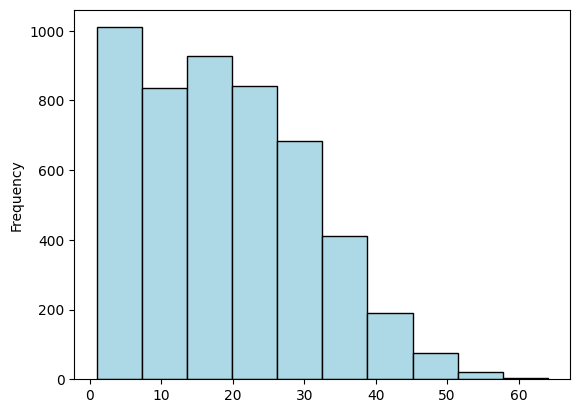

In [55]:
df["exam_score"].plot(kind="hist",color="lightblue",edgecolor="black")

In [56]:
#model building
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [57]:
df

,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,mental_health_score,productivity_score,exam_score
0,0,7.64,1.56,2.20,3.05,2.19,6.52,6.47,10,73.65,50.16
1,0,2.21,2.22,2.10,1.65,2.55,5.97,6.05,3,13.70,1.00
2,0,3.45,0.00,0.29,1.34,2.08,8.39,7.62,8,45.15,18.30
3,0,5.75,2.08,3.01,2.27,2.20,6.31,11.67,3,20.92,9.37
4,0,6.83,1.72,3.33,2.65,0.70,8.01,10.02,8,59.23,27.81
...,...,...,...,...,...,...,...,...,...,...,...
4995,1,3.93,1.42,0.54,2.58,2.62,9.30,6.38,9,48.83,22.51
4996,0,4.00,0.00,3.00,4.45,2.47,6.42,7.32,5,23.32,2.00
4997,1,5.63,2.52,2.89,3.58,1.07,6.65,9.51,7,41.09,27.89
4998,1,3.58,2.83,1.53,5.88,1.28,7.36,8.31,4,12.62,3.63


In [58]:
x=df.drop('exam_score',axis=1)
y=df['exam_score']

In [59]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=80)

In [60]:
x_train

,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,mental_health_score,productivity_score
2151,1,4.14,0.77,2.66,5.33,1.52,8.39,10.60,9,37.17
553,2,3.39,2.85,3.76,1.07,0.66,7.03,4.40,7,42.66
1307,2,3.81,5.06,1.39,1.54,0.00,8.08,3.94,1,9.54
3403,2,6.37,2.81,0.73,4.22,2.05,6.96,6.16,10,69.62
37,1,5.94,0.47,3.15,2.45,2.62,6.74,6.18,10,54.70
...,...,...,...,...,...,...,...,...,...,...
2423,0,1.14,1.63,2.70,2.84,1.12,6.20,4.34,1,1.00
522,2,1.38,2.35,2.17,3.20,0.67,7.02,1.00,5,11.99
2259,2,2.94,1.41,1.76,1.73,3.69,6.59,7.99,4,20.88
2982,2,7.13,0.92,0.59,3.56,0.78,6.28,5.77,4,30.42


In [61]:
y_train

2151    13.29
553     18.55
1307     6.98
3403    37.02
37      29.22
        ...  
2423     1.00
522      1.00
2259     9.09
2982    14.98
1199    12.05
Name: exam_score, Length: 4000, dtype: float64

In [62]:
model=LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [63]:
y_predict=model.predict(x_test)
y_predict

array([ 2.56185273e+01,  4.14737945e+01,  1.84718586e+01,  8.49818293e+00,
        8.92609899e+00,  4.16905043e+01,  1.37315099e+01,  1.06968273e+01,
        8.24866935e+00,  1.91874634e+01,  3.78959832e+00,  1.36365786e+01,
        1.79830420e+01,  2.25760419e+01,  2.62360980e+01,  1.55434993e+01,
        1.41824890e+01,  2.88315370e+01,  1.24584664e+01,  1.06454579e+01,
        1.29875051e+01,  2.62030873e+01,  1.34042237e+01,  1.61149122e+01,
        1.26212615e+01,  1.86873969e+01,  2.72606601e+01,  1.74513756e+01,
        2.57996765e+01,  2.45238806e+01,  1.62118663e+01,  3.15141035e+01,
        2.61175270e+01,  1.78384560e+01,  3.61487034e+01,  8.51657423e+00,
        2.57139701e+01,  2.41405903e+01,  1.00675981e+01,  5.94356789e+00,
        1.94525326e+01,  9.32829194e+00,  1.02304580e+01,  4.44000151e+00,
        2.32036917e+01,  2.18224579e+01,  1.14820853e+01,  8.31417792e+00,
        1.86418720e+01, -2.53490704e+00,  1.54850457e+01,  2.54170860e+01,
        1.47345901e+01,  

In [64]:
print ("the mean absolute error of model is",mean_absolute_error(y_test,y_predict))

the mean absolute error of model is 4.1921042646971545


In [65]:
import joblib

joblib.dump(model, 'model.pkl')

['model.pkl']